<a href="https://colab.research.google.com/github/farrel-ctrl/FSD-LINEAR-REGRESSION/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("darkmatternet/ultimate-pokmon-dataset-2025")

print("Path to dataset files:", path)

100%|██████████| 122k/122k [00:00<00:00, 10.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/darkmatternet/ultimate-pokmon-dataset-2025/versions/1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import os

print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

csv_file_name = 'pokemon_complete_2025.csv'
full_csv_path = None
for root, dirs, files in os.walk(path):
    if csv_file_name in files:
        full_csv_path = os.path.join(root, csv_file_name)
        break

if full_csv_path:
    df = pd.read_csv(full_csv_path)
    print(df.head())
else:
    print(f"Error: '{csv_file_name}' not found in the downloaded dataset directory: {path}")
    print("Please check the dataset contents or file name.")

Contents of /root/.cache/kagglehub/datasets/darkmatternet/ultimate-pokmon-dataset-2025/versions/1:
/root/.cache/kagglehub/datasets/darkmatternet/ultimate-pokmon-dataset-2025/versions/1/pokemon_complete_2025.csv
   pokedex_id        name           genus generation type_1  type_2  \
0           1   bulbasaur    Seed Pokémon          I  grass  poison   
1           2     ivysaur    Seed Pokémon          I  grass  poison   
2           3    venusaur    Seed Pokémon          I  grass  poison   
3           4  charmander  Lizard Pokémon          I   fire     NaN   
4           5  charmeleon   Flame Pokémon          I   fire     NaN   

   num_types  hp  attack  defense  ...  \
0          2  45      49       49  ...   
1          2  60      62       63  ...   
2          2  80      82       83  ...   
3          1  39      52       43  ...   
4          1  58      64       58  ...   

                                          sprite_url  is_dual_type   bmi  \
0  https://raw.githubusercontent.

Pada tahap ini, kami mengimpor library utama seperti pandas untuk manipulasi tabel dan sklearn untuk algoritma machine learning. Kami menggunakan dataset Ultimate Pokémon 2025 yang berisi informasi statistik Pokémon. Output di atas menunjukkan 5 baris pertama untuk memastikan data terbaca dengan benar.


Tampilan 5 Data Teratas:


,pokedex_id,name,genus,generation,type_1,type_2,num_types,hp,attack,defense,...,sprite_url,is_dual_type,bmi,attack_defense_ratio,physical_total,special_total,offensive_total,defensive_total,gender_distribution,stat_tier
0,1,bulbasaur,Seed Pokémon,I,grass,poison,2,45,49,49,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,14.1,1.00,98,130,159,159,88% Male / 12% Female,Below Average (300-399)
1,2,ivysaur,Seed Pokémon,I,grass,poison,2,60,62,63,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,13.0,0.98,125,160,202,203,88% Male / 12% Female,Average (400-499)
2,3,venusaur,Seed Pokémon,I,grass,poison,2,80,82,83,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,25.0,0.99,165,200,262,263,88% Male / 12% Female,Strong (500-599)
3,4,charmander,Lizard Pokémon,I,fire,NaN,1,39,52,43,...,https://raw.githubusercontent.com/PokeAPI/spri...,False,23.6,1.21,95,110,177,132,88% Male / 12% Female,Below Average (300-399)
4,5,charmeleon,Flame Pokémon,I,fire,NaN,1,58,64,58,...,https://raw.githubusercontent.com/PokeAPI/spri...,False,15.7,1.10,122,145,224,181,88% Male / 12% Female,Average (400-499)


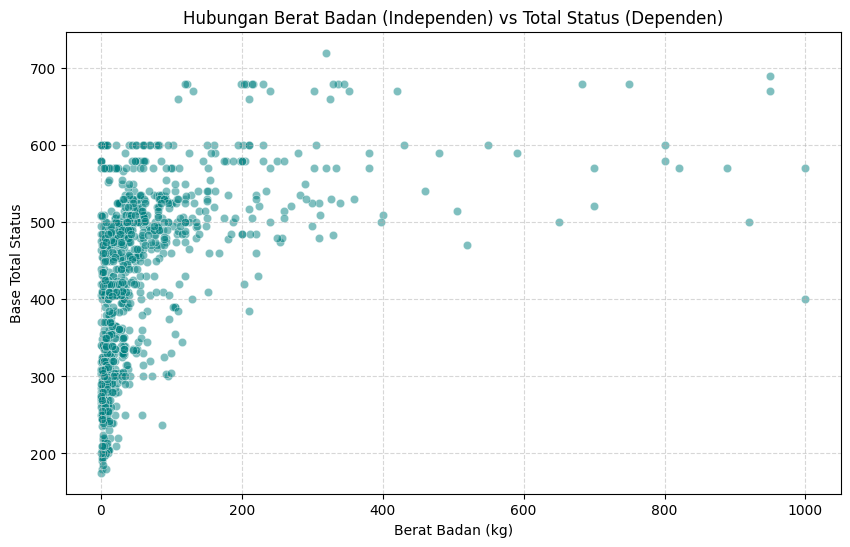

In [3]:
print("Tampilan 5 Data Teratas:")
display(df.head())

df['base_total'] = df['hp'] + df['attack'] + df['defense'] + df['special_total'] + df['speed']

data_clean = df[['weight_kg', 'base_total']].dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_clean, x='weight_kg', y='base_total', color='teal', alpha=0.5)
plt.title('Hubungan Berat Badan (Independen) vs Total Status (Dependen)')
plt.xlabel('Berat Badan (kg)')
plt.ylabel('Base Total Status')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Kami memilih Weight_kg sebagai fitur independen karena secara logika Pokémon yang lebih besar/berat seringkali memiliki status yang lebih kuat. Kami menggunakan .dropna() karena algoritma Linear Regression tidak dapat memproses nilai kosong (NaN). Grafik scatter plot menunjukkan adanya kecenderungan data bergerak ke arah kanan atas, yang menandakan adanya korelasi positif.


In [4]:
X = data_clean[['weight_kg']]
y = data_clean['base_total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Linear Regression berhasil dibuat dan dilatih.")

Model Linear Regression berhasil dibuat dan dilatih.


Kami membagi dataset menjadi dua bagian menggunakan train_test_split. Data Training digunakan agar model dapat mempelajari pola hubungan antara berat dan status, sedangkan data Testing digunakan untuk menguji seberapa akurat model memprediksi data baru yang belum pernah dilihat sebelumnya.

In [5]:
y_pred = model.predict(X_test)

print(f"Slope (Koefisien): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

Slope (Koefisien): 0.4142
Intercept: 399.3748
Mean Squared Error (MSE): 9277.72
R2 Score: 0.2879


Berdasarkan hasil evaluasi:

Slope: Menunjukkan setiap kenaikan 1 kg berat badan, diprediksi akan menambah nilai status sebesar poin tertentu.

R2 Score: Memberikan informasi seberapa baik variasi berat badan dapat menjelaskan variasi total status. Jika nilai R2 rendah, hal ini wajar karena kekuatan Pokémon juga ditentukan oleh variabel lain seperti type atau legendary status.

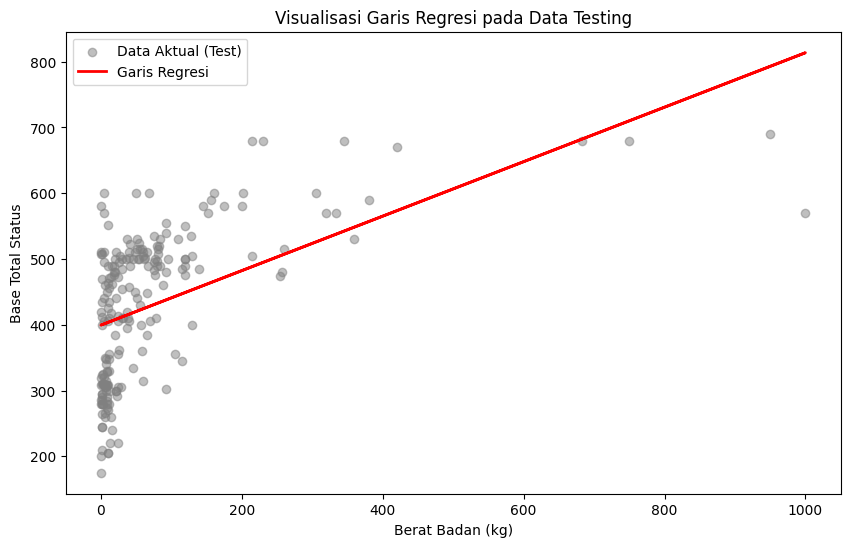

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Data Aktual (Test)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Garis Regresi')
plt.title('Visualisasi Garis Regresi pada Data Testing')
plt.xlabel('Berat Badan (kg)')
plt.ylabel('Base Total Status')
plt.legend()
plt.show()

Grafik ini membandingkan data aktual (titik abu-abu) dengan prediksi model (garis merah). Garis merah merepresentasikan estimasi terbaik dari hubungan linear antara kedua variabel. Jarak antara titik-titik data ke garis merah menunjukkan besarnya error dari model yang dibuat.